# QD MPMS3 Data Plotter
This code relies on importing a python file containing the Class definitions.


In [10]:
#The following two lines update the file. If you want to update the utility file without restarting the kernel/python server
from QD_MPMS3_plotter_tools import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load a Moment vs Temperature data file

In [70]:
# Fe2O3_on_Al2O3_sub_MT 500 Oe
Fe2O3_on_Al2O3_MT = MTMeasurement("Fe2O3_on_Al2O3_MT 500 Oe.dat")

In [71]:
print(Fe2O3_on_Al2O3_MT.data.columns)

Index(['Comment', 'Time Stamp (sec)', 'Temperature (K)', 'Magnetic Field (Oe)',
       'Moment (emu)', 'M. Std. Err. (emu)', 'Transport Action',
       'Averaging Time (sec)', 'Frequency (Hz)', 'Peak Amplitude (mm)',
       'Center Position (mm)', 'Lockin Signal' (V)', 'Lockin Signal (V)',
       'Range', 'M. Quad. Signal (emu)', 'AC Moment (emu)',
       'AC M. Std Err. (emu)', 'AC Phase (deg)', 'AC Phase Std. Err. (deg)',
       'AC Susceptibility (emu/Oe)', 'AC Suscept. Std Err. (emu/Oe)',
       'AC X' (emu/Oe)', 'AC X' Std Err. (emu/Oe)', 'AC X'' (emu/Oe)',
       'AC X'' Std Err. (emu/Oe)', 'AC Drive (Oe)', 'AC Frequency (Hz)',
       'AC Averaging Time (sec)', 'AC Cycles', 'AC Range', 'AC Measure Type',
       'AC Signal' (V)', 'AC Signal'' (V)', 'AC Trim Coil Ratio',
       'AC Trim Coil Phase', 'Min. Temperature (K)', 'Max. Temperature (K)',
       'Min. Field (Oe)', 'Max. Field (Oe)', 'Mass (grams)', 'Motor Lag (deg)',
       'Pressure (Torr)', 'Measure Count', 'Measurement N

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Moment vs Temperature'}, xlabel='Temperature (K)', ylabel='Moment (emu)'>)

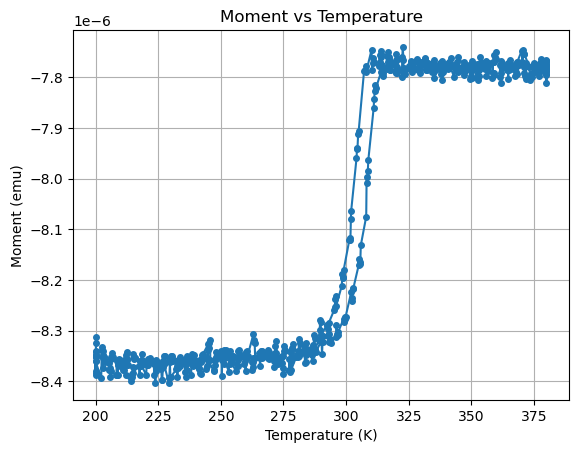

In [72]:
Fe2O3_on_Al2O3_MT.plot_m_vs_t()

## Load in the data into arrays from the object
If you want to perform your own analyis e.g. differentiation, flattening

In [73]:
x = Fe2O3_on_Al2O3_MT.get_column('Temperature (K)')
y = Fe2O3_on_Al2O3_MT.get_column('Moment (emu)')

# Load a Moment vs H-field data file

In [74]:
# Analyze an M-H dataset
Fe2O3_340K = MHMeasurement("Fe2O3_on_Al2O3_MH-IP-340K.dat")


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Hysteresis Loop'}, xlabel='Magnetic Field (Oe)', ylabel='Moment (emu)'>)

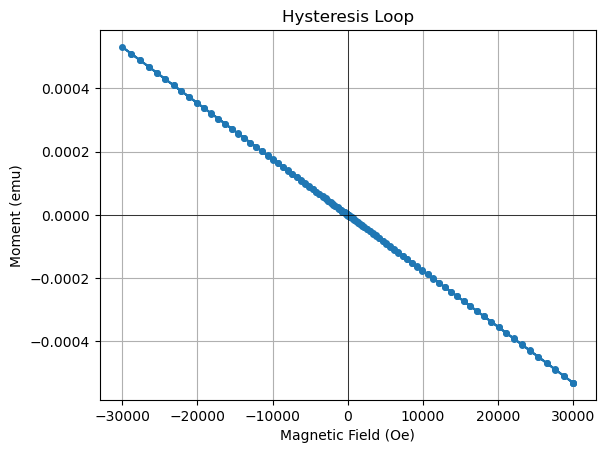

In [76]:
Fe2O3_340K.plot_m_vs_h()

## Load two MH files into a DualMHMeasurement Class
Using this we are able to perform subtraction of two MH loops (one above and one below the Morin transition)

In [150]:
Dual_MH = DualMHMeasurement("Fe2O3_on_Al2O3_MH-IP-200K.dat", "Fe2O3_on_Al2O3_MH-IP-340K.dat")

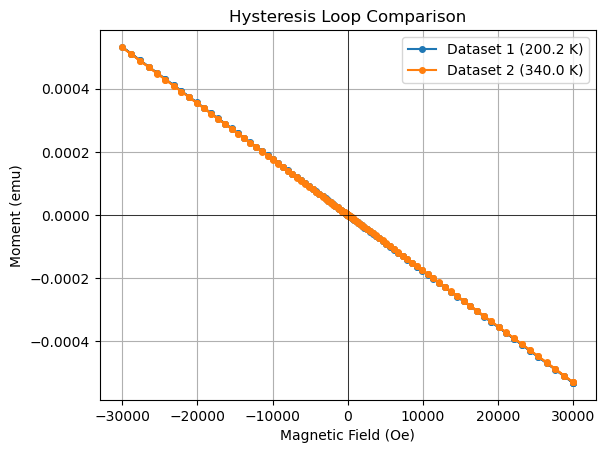

In [151]:
fig, ax = Dual_MH.plot_m_vs_h()

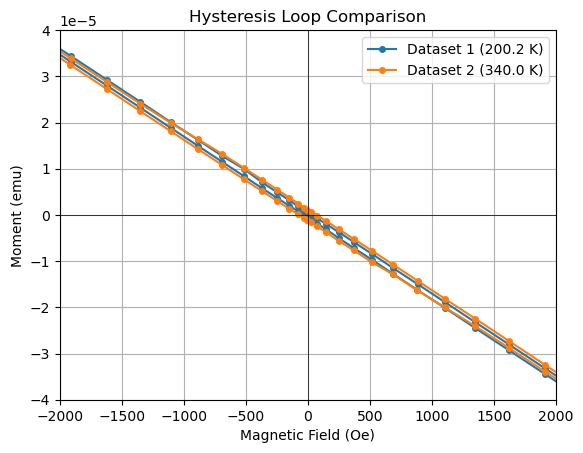

In [152]:
ax.set_xlim(-2000, 2000)
ax.set_ylim(-40e-6, 40e-6)
# Replot the ax object to update the legend with the new x-limits
fig

In [153]:
Dual_MH.subtract_diamagnetic_background()

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Hysteresis Loop Comparison'}, xlabel='Magnetic Field (Oe)', ylabel='Moment (emu)'>)

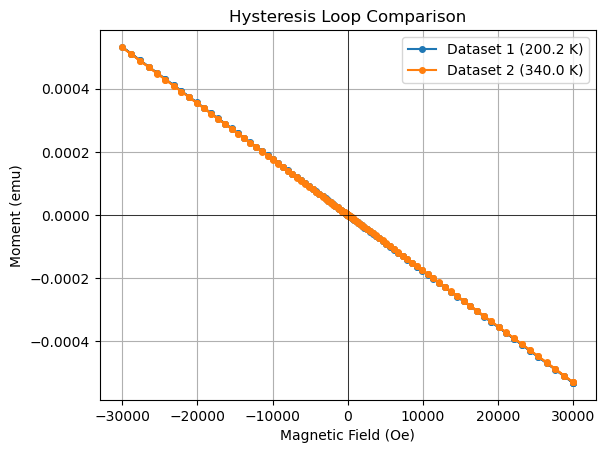

In [154]:
Dual_MH.plot_m_vs_h()

In [155]:
x, y = Dual_MH.h1, Dual_MH.difference, 

(-5000.0, 5000.0)

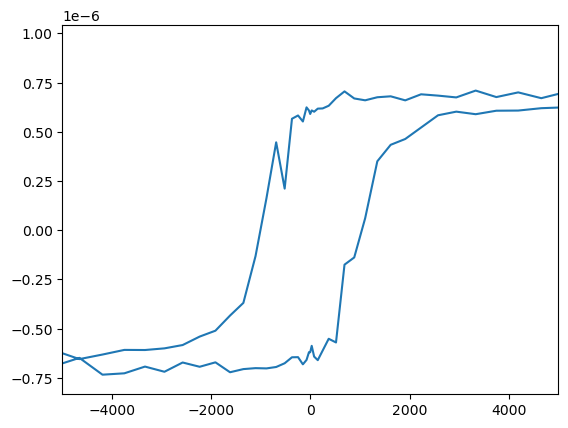

In [158]:
plt.plot(x, y)
plt.xlim(-5000, 5000)